# 03 — Understanding Demand

**Question this notebook answers:** *What does demand for Los Angeles city services look like through the MyLA311 system?*

This is a deliberately broad survey — no single category deep-dives, no maps, no performance analysis. The output is an understanding of the system's shape, plus evidence-based candidates for future case studies.

## Filtering decisions (per [`analysis_standards.md`](../docs/analysis_standards.md) §1)

Standard operational filter:

- **Exclude intake artifacts** (`Information-Only`, `Feedback`, `Program Research`) — call-center Q&A, not service demand.
- **Exclude dead statuses** (`Cancelled`, `Potential Duplicate`, `Duplicate Confirm`) and **duplicate-coded closures** (`DUP-*`, `B-Duplicated Request`, `CDR-*`) — not real serviced demand.
- **Keep `Reported` cases** — this is a *demand* analysis, and encampment/violation reports are real demand even though no individual work order exists.
- **Keep internal channels** (`Driver Self Reported`, `recycLA Service Provider`) — we examine them explicitly in the sources section.
- **Additional decision for this notebook:** analysis restricted to cases created **January 1 – June 30, 2026** (six complete months). The snapshot was taken July 6; including a 5.5-day July would distort monthly and per-day figures.

## Assumptions stated (standards §6)

Reports ≠ problems (we measure *reporting*, not street conditions); one case ≠ one unique problem (re-reports are not linked); single-era scope (2026 system only). Snapshot censoring doesn't bias *counts* of created cases, only duration metrics, which we don't compute here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

raw = pd.read_csv(Path("../data/raw/myla311_cases_2026.csv"), low_memory=False)

INTAKE_ARTIFACTS = {"Information-Only", "Feedback", "Program Research"}
DEAD_STATUSES = {"Cancelled", "Potential Duplicate", "Duplicate Confirm"}
DUP_CODES = ("DUP-", "B-Duplicated", "CDR-")

def standard_operational_filter(df):
    """Standard filter per docs/analysis_standards.md section 1."""
    out = df[~df["RequestType"].isin(INTAKE_ARTIFACTS)]
    out = out[~out["Status"].isin(DEAD_STATUSES)]
    out = out[~out["ResolutionCode"].fillna("").str.startswith(DUP_CODES)]
    return out

op = standard_operational_filter(raw).copy()
op["created"] = pd.to_datetime(op["CreatedDate"], format="mixed")
d = op[op["created"] < "2026-07-01"].copy()  # six complete months

print(f"raw cases:          {len(raw):>9,}")
print(f"after std filter:   {len(op):>9,}  ({len(op)/len(raw):.1%} of raw)")
print(f"Jan-Jun analysis set: {len(d):>7,}")

raw cases:          1,209,648
after std filter:     824,982  (68.2% of raw)
Jan-Jun analysis set: 803,955


A third of the dataset disappears before we start — worth internalizing: **32% of "311 cases" are not serviceable demand** (24% intake artifacts, ~8% cancelled/duplicates). Any headline statistic computed on the raw file overstates demand by half again.

*New tool note:* **matplotlib** is Python's foundational plotting library — most other charting tools are layers on top of it. We use it (via pandas' built-in `.plot()` wrapper, which turns a Series/DataFrame directly into a chart) because it's zero-ceremony for exploratory bar/line charts. `%matplotlib inline` rendering is automatic in modern Jupyter.

## 1. Overall scale

Total Jan-Jun:  803,955
Per day:        4,442 average
Busiest day:    2026-03-25 (13,311)
Quietest day:   2026-04-04 (2,020)


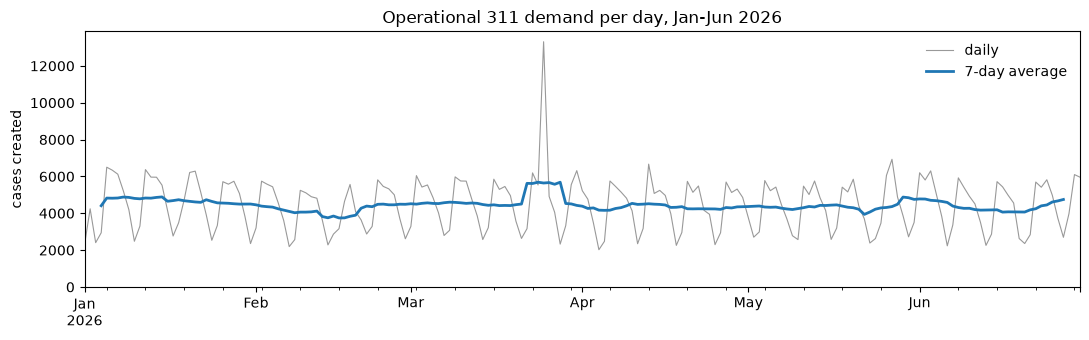

In [2]:
daily = d.set_index("created").resample("D").size()

fig, ax = plt.subplots(figsize=(11, 3.5))
daily.plot(ax=ax, lw=0.8, color="#999", label="daily")
daily.rolling(7, center=True).mean().plot(ax=ax, lw=2, color="tab:blue", label="7-day average")
ax.set_title("Operational 311 demand per day, Jan-Jun 2026")
ax.set_ylabel("cases created")
ax.set_xlabel("")
ax.legend(frameon=False)
ax.set_ylim(bottom=0)
plt.tight_layout()

print(f"Total Jan-Jun:  {len(d):,}")
print(f"Per day:        {len(d)/181:,.0f} average")
print(f"Busiest day:    {daily.idxmax():%Y-%m-%d} ({daily.max():,})")
print(f"Quietest day:   {daily.idxmin():%Y-%m-%d} ({daily.min():,})")

**What it shows:** ~804K operational cases in six complete months — **~4,400 per day, on pace for ~1.6M/year**. The gray line is raw daily counts; the blue line smooths out the weekly rhythm (`rolling(7)` averages each day with its surrounding week — the standard way to see trend through weekly cycles).

**Why it matters:** this is the baseline scale of LA's reported-maintenance economy. Demand is remarkably *steady* — no month collapses or explodes.

**Caveats:** these are *reports*, not problems; internal channels (~1%) are included. And the spike visible on **March 25 is not real demand**: 8,201 cases were created in the 11am hour alone, 7,585 of them `Streetlight Repair Services`, mostly labeled `Mobile App` — a **batch import** (plausibly a backlog transferred from the Bureau of Street Lighting's own system). Two consequences: streetlight volume for H1 is inflated ~30% by one event, and most of the year's "Mobile App" channel volume is this batch, not organic app usage.

created
Jan    140687
Feb    116911
Mar    149359
Apr    130628
May    131344
Jun    135026
dtype: int64

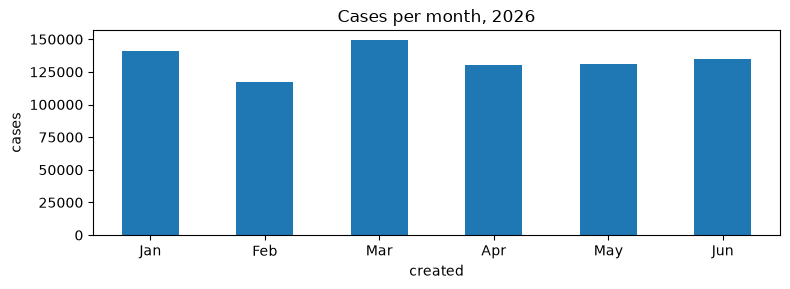

In [3]:
monthly = d.set_index("created").resample("MS").size()
monthly.index = monthly.index.strftime("%b")
ax = monthly.plot(kind="bar", figsize=(8, 3), color="tab:blue", rot=0)
ax.set_title("Cases per month, 2026")
ax.set_ylabel("cases")
plt.tight_layout()
monthly

**What it shows:** monthly volume sits in a narrow band (117K–149K). February is lowest (3 fewer days + rain season), March highest.

**Why it matters:** at the citywide, all-category level there is **no dramatic seasonality in the first half of 2026** — winter/summer contrasts, if they exist, live inside individual categories. We can't see autumn at all yet.

**Caveat:** six months cannot establish seasonal patterns; this only bounds them.

## 2. Request categories

Top 2 categories: 58% of all demand


Top 5:  78%
Top 10: 89%
Bottom 40 categories combined: 5.0%


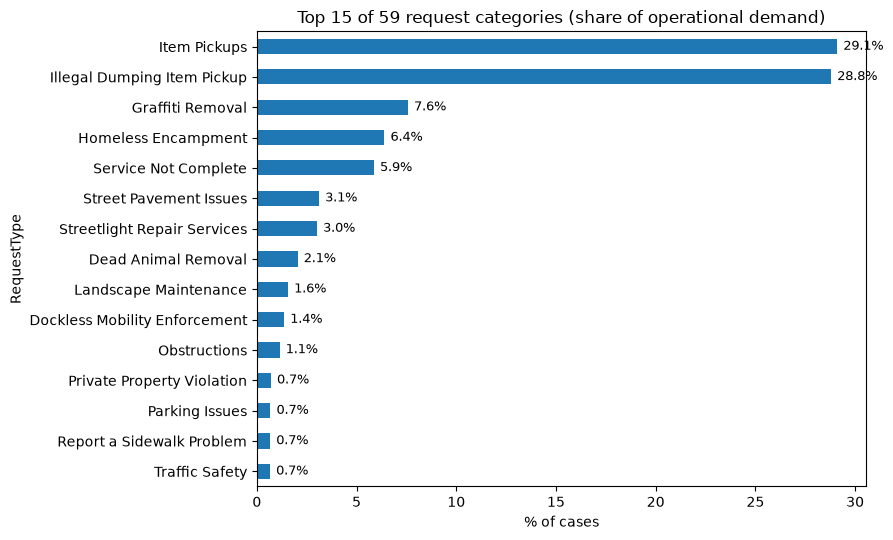

In [4]:
cats = d["RequestType"].value_counts()
share = cats / len(d) * 100

top15 = share.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
top15.plot(kind="barh", ax=ax, color="tab:blue")
for i, v in enumerate(top15):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_title(f"Top 15 of {cats.size} request categories (share of operational demand)")
ax.set_xlabel("% of cases")
plt.tight_layout()

print(f"Top 2 categories: {share.head(2).sum():.0f}% of all demand")
print(f"Top 5:  {share.head(5).sum():.0f}%")
print(f"Top 10: {share.head(10).sum():.0f}%")
print(f"Bottom 40 categories combined: {share.tail(40).sum():.1f}%")

**What it shows:** demand is *extremely* concentrated. `Item Pickups` (29.1%) and `Illegal Dumping Item Pickup` (28.8%) — together **58% of everything** — are both LASAN item-collection workflows. Add graffiti (7.6%), encampments (6.4%), and missed collections (5.9%), and five categories cover 78%. The other 54 categories share 22%; the bottom 40 share 5%.

**Why it matters:** *through the 311 lens, LA's maintenance demand is mostly a logistics problem: picking discarded objects off streets.* Roads, lights, sidewalks, signals — the classic "infrastructure" — are single-digit percentages each. Where the city spends attention (and where our case studies should start) follows this distribution, not our intuitions.

**Caveats:** category granularity shapes ranking (one "item pickup" concept is split into two huge types — open question O2); report-prone categories (visible, sidewalk-level) are overrepresented relative to, say, pavement wear that nobody phones in.

## 3. How requests enter the system

,operational demand (this notebook),all raw cases (incl. Information-Only)
RequestSource,,
Internal/staff,1.4,1.8
Mobile App,0.5,0.3
Other,0.2,0.3
Phone,36.1,49.7
Website,61.8,47.9


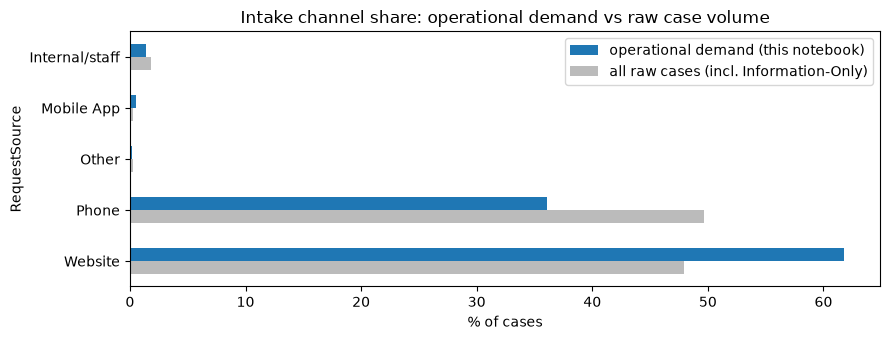

In [5]:
CHANNEL_GROUPS = {
    "Call": "Phone", "Voicemail": "Phone",
    "Self Service": "Website", "Web Form": "Website", "Chat": "Website",
    "Mobile App": "Mobile App",
    "Driver Self Reported": "Internal/staff", "Driver Self Report": "Internal/staff",
    "recycLA Service Provider": "Internal/staff", "Council's Office": "Internal/staff",
    "Mayor's Office": "Internal/staff", "City Attorney": "Internal/staff",
}
grp = d["RequestSource"].map(CHANNEL_GROUPS).fillna("Other")
ops_share = grp.value_counts() / len(d) * 100

raw_grp = raw["RequestSource"].map(CHANNEL_GROUPS).fillna("Other")
raw_share = raw_grp.value_counts() / len(raw) * 100

comp = pd.DataFrame({"operational demand (this notebook)": ops_share,
                     "all raw cases (incl. Information-Only)": raw_share}).round(1)
ax = comp.plot(kind="barh", figsize=(9, 3.5), color=["tab:blue", "#bbb"])
ax.invert_yaxis()
ax.set_title("Intake channel share: operational demand vs raw case volume")
ax.set_xlabel("% of cases")
plt.tight_layout()
comp

**What it shows:** for *operational* demand, the **website dominates: 62% vs 36% phone**. But in the raw file the order reverses (phone ~50%). The difference is Information-Only: phone calls disproportionately produce Q&A entries, not work.

**Why it matters — two findings:**
1. **The channel story depends entirely on the filtering decision.** Any claim like "most 311 requests come by phone" is true of call volume and false of service demand.
2. **Mobile App is 0.5%.** The old system's app was a flagship channel; either usage collapsed in migration or app submissions are being labeled `Self Service` (open question O4). Until resolved, we treat Website+App as one self-service channel.

**Caveats:** `Internal/staff` (~1.5%) includes crews reporting what they find (`Driver Self Reported`, mostly dumping/items) — demand *discovered*, not *reported*; channel mix varies by neighborhood, which matters for any equity claim later.

## 4. Demand over time

Weekday avg: 131,796   Saturday: 64,444   Sunday: 80,531


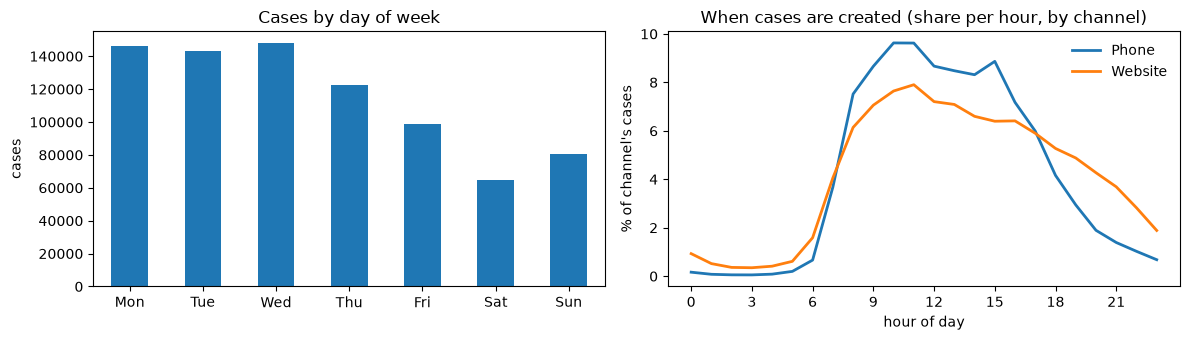

In [6]:
dow = d["created"].dt.dayofweek.value_counts().sort_index()
dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
hr_call = d.loc[d["RequestSource"] == "Call", "created"].dt.hour.value_counts(normalize=True).sort_index() * 100
hr_web = d.loc[d["RequestSource"] == "Self Service", "created"].dt.hour.value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
dow.plot(kind="bar", ax=axes[0], color="tab:blue", rot=0)
axes[0].set_title("Cases by day of week")
axes[0].set_ylabel("cases")
hr_call.plot(ax=axes[1], lw=2, label="Phone")
hr_web.plot(ax=axes[1], lw=2, label="Website")
axes[1].set_title("When cases are created (share per hour, by channel)")
axes[1].set_xlabel("hour of day")
axes[1].set_ylabel("% of channel's cases")
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend(frameon=False)
plt.tight_layout()

print(f"Weekday avg: {dow[:5].mean():,.0f}   Saturday: {dow['Sat']:,}   Sunday: {dow['Sun']:,}")

**What it shows:**
- **Weekdays run ~2x Saturday.** Mon–Wed are peak (~147K each), then volume slides through the week. Curiously, **Sunday (81K) is 25% busier than Saturday (64K)** — consistent with residents prepping bulky-item pickups ahead of the collection week and weekend dumping being noticed/reported before Monday, though we haven't tested that here.
- **Hourly patterns are channel artifacts.** Phone volume lives inside call-center hours (7am–5pm, peaking 10–11am). Website submissions spread through the evening — a real 24/7 channel (with a curious small bump after midnight).

**Why it matters:** "when is demand created" mostly measures *when reporting is possible*, not when problems occur. Any time-of-day analysis must segment by channel or it just rediscovers the call center's schedule.

**Caveat:** timestamps are creation times; a Sunday-spotted problem phoned in Monday counts as Monday demand.

## 5. Geography, high level

CD range: min 42,620 (CD15)  max 64,280 (CD10)  ratio 1.5x
Unassigned CD=0: 372 | missing CD: 2,354


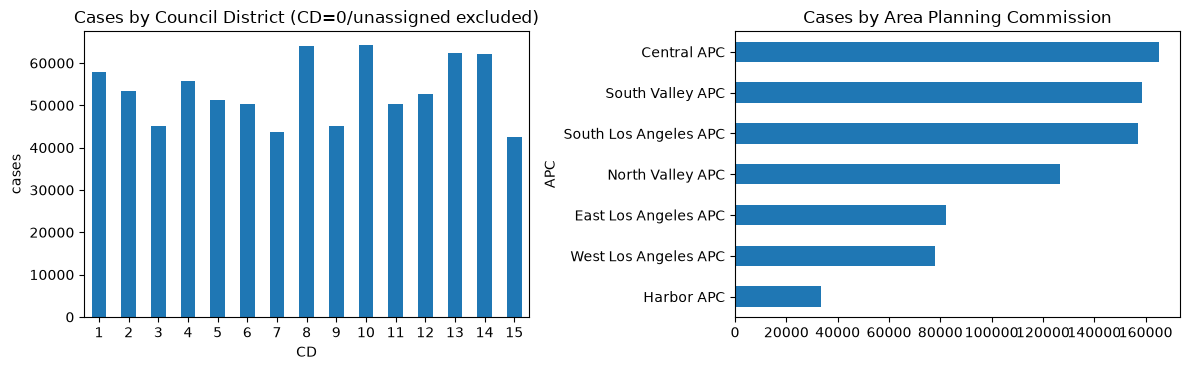

In [7]:
cd_counts = d[d["CD"] > 0]["CD"].astype(int).value_counts().sort_index()
apc = d["APC"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
cd_counts.plot(kind="bar", ax=axes[0], color="tab:blue", rot=0)
axes[0].set_title("Cases by Council District (CD=0/unassigned excluded)")
axes[0].set_ylabel("cases")
apc.iloc[::-1].plot(kind="barh", ax=axes[1], color="tab:blue")
axes[1].set_title("Cases by Area Planning Commission")
plt.tight_layout()

print(f"CD range: min {cd_counts.min():,} (CD{cd_counts.idxmin()})  max {cd_counts.max():,} (CD{cd_counts.idxmax()})  ratio {cd_counts.max()/cd_counts.min():.1f}x")
print(f"Unassigned CD=0: {(d['CD'] == 0).sum():,} | missing CD: {d['CD'].isna().sum():,}")

NC coverage: 98.1% of cases have an NC
Top NC (WILSHIRE CENTER - KOREATOWN NC): 22,632 | median NC: 7,658 | smallest: 835


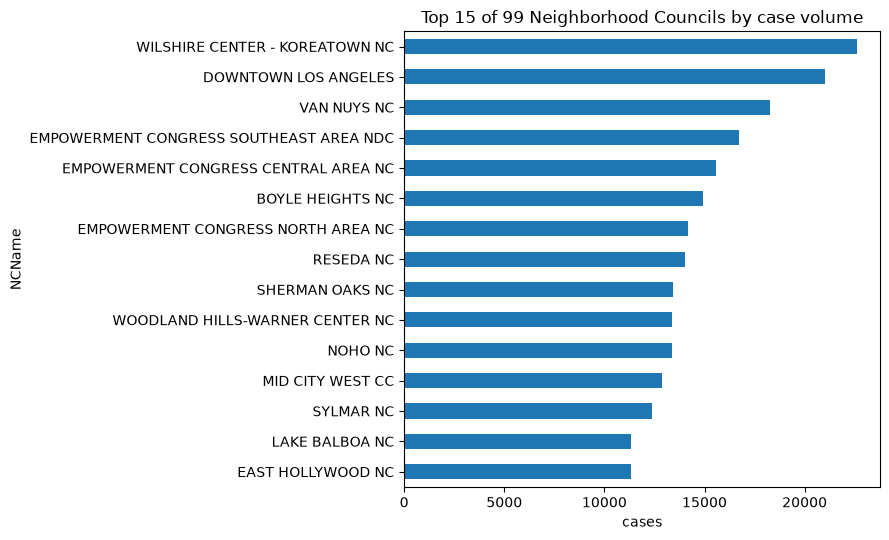

In [8]:
nc = d["NCName"].value_counts()
top15nc = nc.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5.5))
top15nc.plot(kind="barh", ax=ax, color="tab:blue")
ax.set_title(f"Top 15 of {nc.size} Neighborhood Councils by case volume")
ax.set_xlabel("cases")
plt.tight_layout()

print(f"NC coverage: {(1 - d['NCName'].isna().mean()):.1%} of cases have an NC")
print(f"Top NC ({nc.index[0]}): {nc.iloc[0]:,} | median NC: {nc.median():,.0f} | smallest: {nc.iloc[-1]:,}")

**What it shows:**
- **Council districts are surprisingly even**: 43K (CD15, Harbor) to 64K (CD10, Mid-City) — only a **1.5x spread** across districts of roughly equal population (~260K each). Leaders: CD10, CD8 (South LA), CD13, CD14 (Hollywood/Downtown/Eastside).
- **APC view:** Central, South Valley, and South LA each carry ~160K; Harbor is small (but also least populous).
- **Neighborhood Councils spread 27x** (Wilshire Center-Koreatown 22.6K, Downtown 21K … Hermon 835) — though NC areas differ hugely in population, so raw counts partly measure NC size.

**Why it matters:** at *citywide governance* granularity, demand is broadly distributed — no council district is an outlier, which is itself notable. The interesting variation clearly lives at sub-district scale (the NC spread), which is where hotspot work should aim.

**Caveats (important):** raw counts, **not per-capita, not per-road-mile** — normalization comes later, with proper boundary/population data; reporting propensity differs by neighborhood (quiet ≠ clean, standards §6); ~2% of cases lack NC assignment; NC boundaries are political, not "neighborhoods".

## 6. Operational overview — who receives this demand

LASAN group share (LASAN + LSD + recycLA): 72%


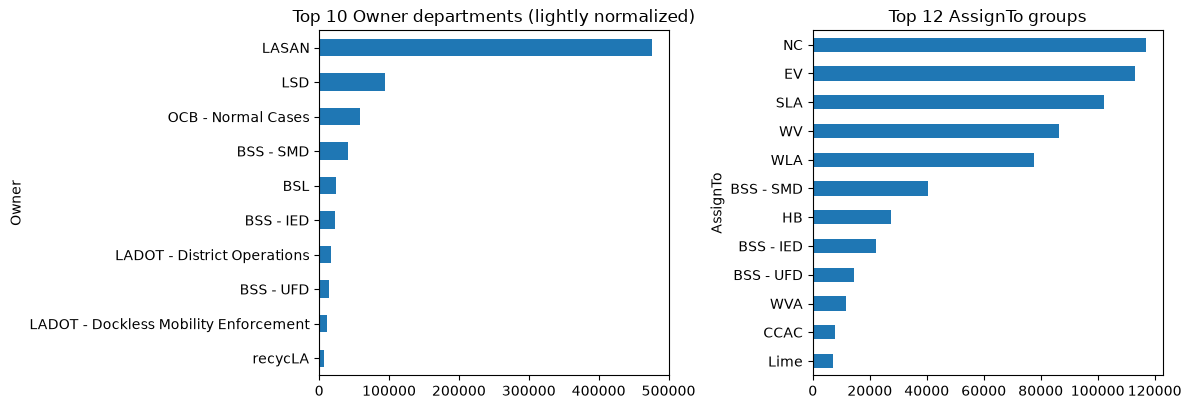

In [9]:
OWNER_NORMALIZE = {"LASAN - LSD": "LSD", "Sanitation": "LASAN", "street service": "STREETSLA"}
owner = d["Owner"].replace(OWNER_NORMALIZE).value_counts()
assign = d["AssignTo"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
owner.head(10).iloc[::-1].plot(kind="barh", ax=axes[0], color="tab:blue")
axes[0].set_title("Top 10 Owner departments (lightly normalized)")
assign.head(12).iloc[::-1].plot(kind="barh", ax=axes[1], color="tab:blue")
axes[1].set_title("Top 12 AssignTo groups")
plt.tight_layout()

print(f"LASAN group share (LASAN + LSD + recycLA): {(owner.get('LASAN',0) + owner.get('LSD',0) + owner.get('recycLA',0)) / len(d):.0%}")

unclassified: 3,686 cases (0.5%)
ResolutionCode
REW-Reschedule for E-Waste               304
AD-Request Completed                     284
ASAT-Appears Safe at This Time           270
UPS-Unable to Provide Desired Service    239
CCAN-Cancelled by Customer               217
PSP-Private Street/Property              206


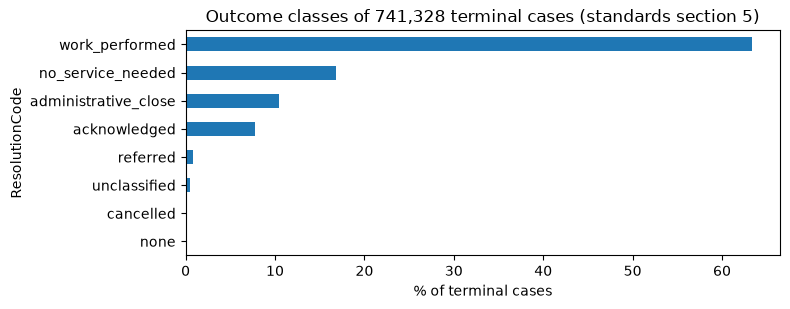

In [10]:
def outcome_class(code):
    """ResolutionCode -> outcome class, per analysis_standards.md section 5."""
    if pd.isna(code):
        return "none"
    c = code.strip()
    if c.startswith(("AR-", "RC-", "COM-", "WC-", "SARH", "SARC", "PFR-", "LR-", "TR-",
                     "BR-", "RSP-", "IWO-", "MNT-", "VM-", "VMRB", "OPUVM", "BF-",
                     "R-Repaired", "TSC-")):
        return "work_performed"
    if c.startswith(("QC-", "NCPP", "ASG-", "UTM-", "NAT-", "VNL-", "NAR-", "BINS-")):
        return "no_service_needed"
    if c.startswith(("C-Closed", "1004", "RF-", "GI-", "IP-", "AAA-", "IO-", "CL-")):
        return "administrative_close"
    if c.startswith("C-Report"):
        return "acknowledged"
    if c.startswith("1003"):
        return "referred"
    if c.startswith(("DUP-", "B-Duplicated", "CDR-")):
        return "duplicate"
    if c.startswith(("RCAN", "1005", "CANC", "CG-", "RBI-", "RWG-")):
        return "cancelled"
    return "unclassified"

terminal = d[d["Status"].isin(["Closed", "Closed Ext-Referred", "Reported"])]
oc = terminal["ResolutionCode"].map(outcome_class).value_counts()

ax = (oc / len(terminal) * 100).iloc[::-1].plot(kind="barh", figsize=(8, 3.2), color="tab:blue")
ax.set_title(f"Outcome classes of {len(terminal):,} terminal cases (standards section 5)")
ax.set_xlabel("% of terminal cases")
plt.tight_layout()

# Standards require printing whatever failed to classify
uncl = terminal.loc[terminal["ResolutionCode"].map(outcome_class) == "unclassified", "ResolutionCode"]
print(f"unclassified: {len(uncl):,} cases ({len(uncl)/len(terminal):.1%})")
print(uncl.value_counts().head(6).to_string())

**What it shows:**
- **LASAN and its divisions receive ~72% of all operational demand** — the 311 system is, operationally, mostly a sanitation dispatch system. StreetsLA divisions (~10%), OCB graffiti (~8%), BSL streetlights (~3%), LADOT (~4%) split the rest.
- **AssignTo:** LASAN's six collection-yard districts (NC, EV, SLA, WV, WLA, HB) are the six biggest workgroups in the city, ahead of every named bureau division and contractor.
- **Outcomes:** of terminal cases, ~64% ended `work_performed`, **~17% `no_service_needed`** (crew responded, nothing to do — the F4 waste signal, now sized on filtered data), ~10% administrative close (outcome unknown), ~8% acknowledged-only reports.

**Why it matters:** demand flow is a funnel — 62 categories → ~15 meaningful departments → a handful of yards and contractors. Understanding LA maintenance mostly means understanding LASAN yards, OCB's contractor network, and StreetsLA divisions.

**Caveats:** this is *flow*, not *performance* — no durations or success rates here. The outcome mapping extension (8 new codes, e.g. `R-Repaired`, `VNL-Vehicle Not at Location`) has been folded back into standards §5 per the unclassified-codes rule; remaining unclassified ≈ 0.6%.

---

## What We Learned

1. **Scale:** ~804K operational cases in six months (~4,400/day, ~1.6M/year pace), remarkably steady month to month.
2. **Composition:** demand is object-removal-dominated — two item-collection categories are 58%, top five are 78% of everything. Classic infrastructure (pavement, lights, sidewalks) is single digits.
3. **Channels:** website is the real front door for service demand (62%); phone volume is largely a Q&A operation; Mobile App is anomalously absent.
4. **Time:** weekly rhythm (weekdays 2x Saturday, Sunday uptick); hourly patterns are channel schedules, not problem schedules.
5. **Geography:** council districts are within 1.5x of each other; the action is at neighborhood scale (27x NC spread, pre-normalization).
6. **Flow:** LASAN group receives ~72% of demand; six collection yards are the city's biggest workgroups; ~17% of terminal cases resolve as "nothing to service."

## What Surprised Us

- **32% of the raw file is not serviceable demand** — the filtering standards changed every number in this notebook, materially.
- **The channel reversal**: phone dominates raw cases, website dominates real demand. Same data, opposite headlines, depending on one filter.
- **How even council districts are.** Given LA's reputation for unequal services, a 1.5x spread in raw demand across CDs was not the expected picture (per-capita normalization pending).
- **Sunday > Saturday** by 25%.
- The scale of `no_service_needed`: roughly **one in six closed cases dispatched capacity to nothing**.

## New Questions Raised

1. Is the Sunday uptick driven by bulky-item scheduling (pickups aligned to collection weeks)? → testable in a case study.
2. What share of the NC-level spread survives per-capita and per-road-mile normalization? → needs boundary/population data (future geographic phase).
3. Does channel mix (phone vs web) vary systematically by neighborhood — i.e., who depends on the phone? → equity-relevant, testable now.
4. What drives `no_service_needed` variation across categories — is 17% uniform, or concentrated in item pickups? (Extends O3.)
5. Do `Driver Self Reported` cases (crew-discovered demand) cluster where resident reporting is low? → a wedge into the reporting-bias problem.
6. Are there other batch-import events like March 25 hiding in specific categories? Any category-level time series should check for single-hour spikes before interpreting trends.

## Candidate Case Studies

Ranked recommendations, justified only by evidence above:

1. **The item-collection complex (`Item Pickups` + `Illegal Dumping Item Pickup`, studied together).** 58% of all demand; the boundary between the two types is undefined (O2); it generates most of the `QC-Item Not Out` waste signal (F4); and it's where the Sunday/collection-week hypothesis lives. Studying either alone would inherit an arbitrary category split — study them as one system. *This subsumes "illegal dumping" rather than assuming it.*
2. **Graffiti Removal.** #3 category (7.6%, ~61K cases); a *closed-loop* workflow (report → contractor → removal) executed by named CBOs with a public 72-hour goal — the only category with an external performance benchmark; demand is steady and high-volume, so results generalize.
3. **Streetlight Repair Services.** ~3% but structurally different from everything above: durable infrastructure repair (single owner BSL, real work orders) rather than object removal. A useful contrast subject for "what does slow look like" — and streetlight outages have documented public-safety salience. *Caveat discovered here: ~30% of its H1 volume is a single March 25 batch import, which any study must segment out first.*
4. **Homeless Encampment (as a demand study only).** 6.4% of demand, 4th largest; but it terminates in `Reported` with no per-case work order, so *performance* is unmeasurable in this data. What is measurable — and worth a notebook — is its demand geography and re-reporting behavior, which likely differs from everything else in the system.
5. *(runner-up)* **Street Pavement Issues** (3.1%): visible SAR scheduling codes suggest an unusually legible internal workflow, but volume and stakes rank below the four above.

**Recommendation for notebook 04: the item-collection complex (#1).** It is the majority of the system, and every methodological muscle we need later (outcome classes, recurrence definitions, channel bias) gets exercised there first.